In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
diabetes = load_diabetes()
X=pd.DataFrame(diabetes.data,columns=diabetes.feature_names)
y=diabetes.target

In [ ]:
print("Missing Values:")
print(X.isnull().sum())
print("Duplicate Rows:", X.duplicated().sum())
print(X.dtypes)

Missing Values:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64
Duplicate Rows: 0
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object


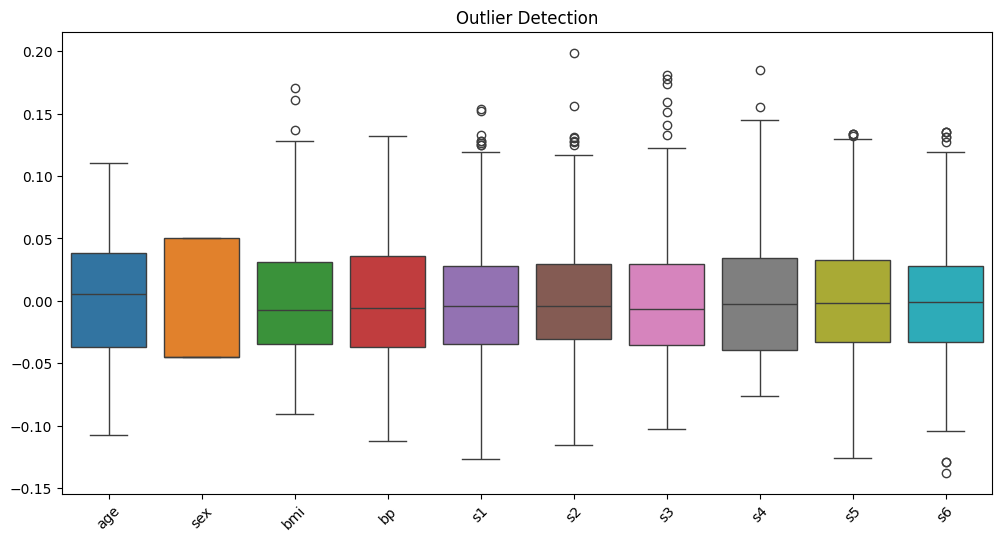

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X)
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

In [ ]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

mask = ~((X < (Q1 - 1.5 * IQR)) |
         (X > (Q3 + 1.5 * IQR))).any(axis=1)

X_clean = X[mask]
y_clean = y[mask]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 45.07326632975784
MSE: 3175.0433507889247
RMSE: 56.34752302265757
R² Score: 0.5186418980582514


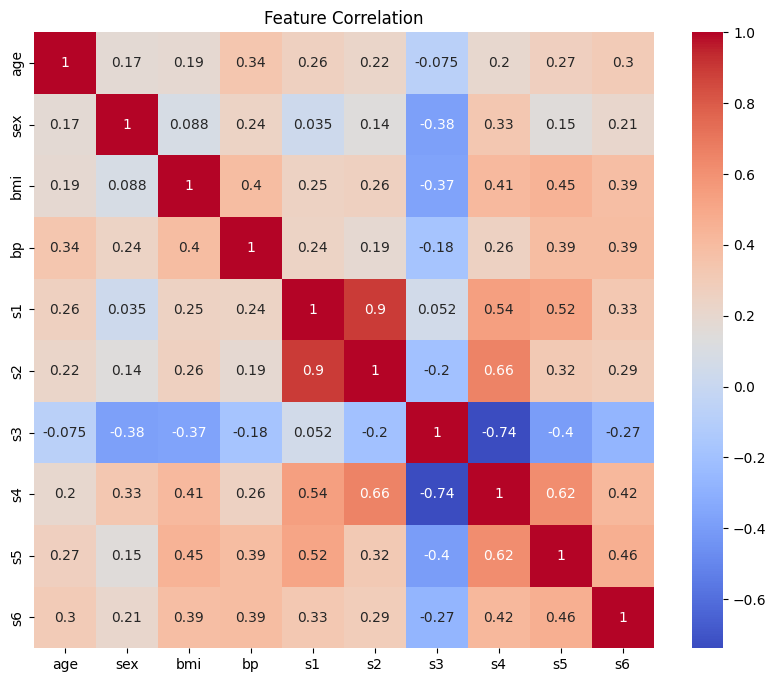

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

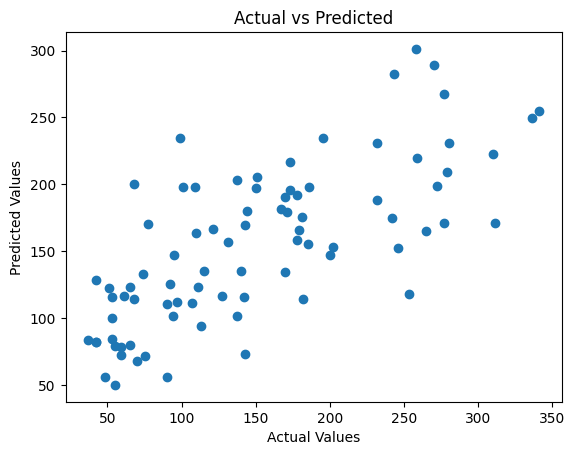

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {
    "Linear Regression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "Decision Tree":DecisionTreeRegressor(random_state=42),
    "Random Forest":RandomForestRegressor(random_state=42)
}

results = {}

for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)

    results[name]=r2_score(y_test,pred)

for k,v in results.items():
    print(k,":",round(v,4))

Linear Regression : 0.5186
Ridge : 0.4401
Lasso : 0.3212
Decision Tree : -0.0874
Random Forest : 0.4896


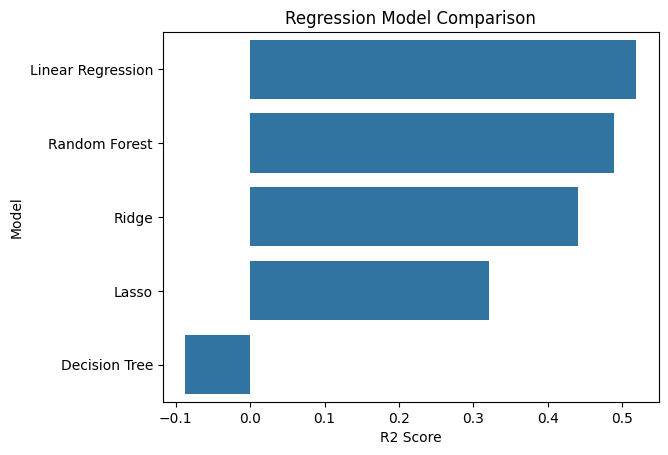

In [ ]:
result_df=pd.DataFrame(
    results.items(),
    columns=["Model","R2 Score"]
)

result_df=result_df.sort_values(
    by="R2 Score",
    ascending=False
)

sns.barplot(
    data=result_df,
    x="R2 Score",
    y="Model"
)

plt.title("Regression Model Comparison")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)[0]

print("Predicted Diabetes Progression Score:", round(prediction,2))
print("Risk Level:", risk_level(prediction))
print("Recommendation:", recommendation(prediction))

Predicted Diabetes Progression Score: 133.71
Risk Level: Medium Risk
Recommendation: Increase exercise and monitor glucose


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [ ]:
def risk_level(score):

    if score < 100:
        return "Low Risk"

    elif score < 200:
        return "Medium Risk"

    else:
        return "High Risk"

In [ ]:
sample = X_test[:1]

prediction = rf.predict(sample)[0]

print("Predicted Score:",prediction)
print("Risk:",risk_level(prediction))

Predicted Score: 133.71
Risk: Medium Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


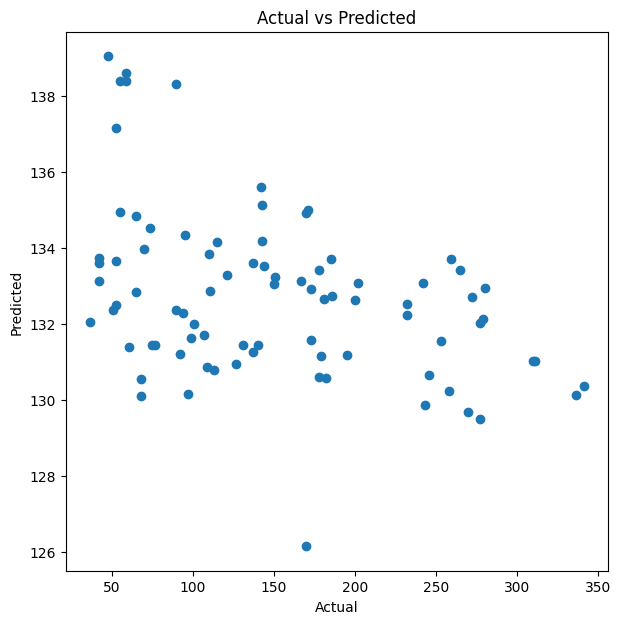

In [ ]:
pred=rf.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test,pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Actual Score": y_test,
    "Predicted Score": pred
})

In [ ]:
from sklearn.metrics import mean_absolute_error

errors=abs(y_test-pred)

print("Average Error:",
      errors.mean())

Average Error: 68.33325301204819


In [ ]:
def recommendation(score):

    if score<100:
        return "Maintain healthy lifestyle"

    elif score<200:
        return "Increase exercise and monitor glucose"

    else:
        return "Consult healthcare professional and monitor regularly"

In [ ]:
print(recommendation(prediction))

Increase exercise and monitor glucose
